# Imports:

In [1]:
!pip install lightgbm xgboost joblib

In [2]:
# All imports

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import GridSearchCV

import joblib


# Model Training, Tuning and Evaluation

## Overview:
This phase focuses on developing a predictive pipeline to estimate employee burnout scores using various machine learning algorithms. We transition from a simple baseline model to sophisticated ensemble techniques to capture non-linear relationships in the behavioral data. The process includes rigorous data splitting, feature scaling for model fairness, and a comparative analysis of five different regression approaches to identify the most accurate predictor.

## Key Objectives:
* **Data Partitioning:** Divide the data into an 80% training set and a 20% testing set to ensure unbiased evaluation.
* **Feature Standardization:** Apply StandardScaler to normalize features, ensuring that models like Linear Regression are not biased by varying feature scales.
* **Performance Benchmarking:** Establish a baseline using Linear Regression and progressively move toward Random Forest, XGBoost, and LightGBM.
* **Model Optimization:** Implement a Stacking Regressor that combines the predictions of multiple base learners to achieve a higher R² score and lower error margins.
* **Metric-Driven Evaluation:** Use Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) for a multi-dimensional assessment of model accuracy.

In [3]:
# Load data
df = pd.read_csv('Data/clean_data.csv')
print(df.shape)
display(df.head())

(842518, 15)


,workload_score,overtime_hours,role_complexity_score,satisfaction_score,team_sentiment,career_progression_score,goal_achievement_rate,meeting_participation,role_encoded,pressure_index,burnout_propensity,effort_efficiency,burnout_pressure,culture_shield,burnout_score
0,0.758117,0.00000,0.2,0.623746,0.662335,1.000000,0.632482,0.492131,0.728387,0.151623,0.00000,0.632482,1.047490,0.413129,0.866643
1,0.788416,0.00000,0.2,0.982556,0.934661,1.000000,0.538587,0.981394,0.756589,0.157683,0.00000,0.538587,0.728291,0.918357,0.218996
2,0.697617,0.00000,0.2,0.767200,0.888559,0.836495,0.624656,0.701138,0.720029,0.139523,0.00000,0.624656,0.804447,0.681703,0.541531
3,0.493143,9.59168,0.2,0.185888,0.732189,1.000000,0.959320,0.339626,0.757336,0.098629,33.55045,0.090573,1.724950,0.136105,1.000000
4,0.567230,0.00000,0.2,0.566706,0.817545,1.000000,0.677305,0.565582,0.726394,0.113446,0.00000,0.677305,0.850794,0.463308,0.614825


In [4]:

# 1. Define Features (X) and Target (y)
X = df.drop(columns=['burnout_score'])
y = df['burnout_score']

# 2. Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

# 3. Feature Scaling
# Tree-based models don't strictly require scaling, but Linear Regression does.
# It's best practice to scale for a fair comparison.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Global list to store model performance
model_performance = []

# 5. Helper function for consistent evaluation
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

    model_performance.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })

(674014, 14)
(168504, 14)


### Baseline model: Linear Regression


In [5]:
# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [6]:
# Predict and Evaluate
lr_preds = lr_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lr_preds)

--- Linear Regression Performance ---
MAE:  0.1482
RMSE: 0.1837
R²:   0.6622



### Model 1: Random Forest

In [7]:
# Initialize and train
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [8]:
# Predict and Evaluate
rf_preds = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, rf_preds)

--- Random Forest Performance ---
MAE:  0.0985
RMSE: 0.1477
R²:   0.7815



### Model 2: XGBoost

In [9]:
# Initialize and train
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [10]:

# Predict and Evaluate
xgb_preds = xgb_model.predict(X_test_scaled)
evaluate_model("XGBoost", y_test, xgb_preds)

--- XGBoost Performance ---
MAE:  0.0951
RMSE: 0.1436
R²:   0.7936



### Model 3: LightGBM

In [11]:
# Convert scaled arrays back to DataFrames to retain feature names
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# 1. Define the base model
# We remove the hyper-parameters here so the grid search can inject them.
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# 2. Define the parameter grid
# Note: In LightGBM, 'num_leaves' is often more important than 'max_depth'. 
# Rule of thumb: num_leaves should be <= 2^(max_depth).
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'num_leaves': [31, 63] 
}

# 3. Setup GridSearchCV
# We use cv=3 to save time given the 850k rows. 
# Change 'scoring' to match whatever your evaluate_model function prioritizes (e.g., 'neg_root_mean_squared_error', 'r2')
grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error', 
    cv=3,
    verbose=2, # Set to 2 to print progress and see how long each fit takes
    n_jobs=-1  # Use all available CPU cores
)

# 4. Fit the model
print("Starting Grid Search...")
grid_search.fit(X_train_final, y_train)

# 5. Extract the best model and parameters
print(f"\nBest parameters found: {grid_search.best_params_}")
best_lgb_model = grid_search.best_estimator_


Starting Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023784 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3314
[LightGBM] [Info] Number of data points in the train set: 674014, number of used features: 14
[LightGBM] [Info] Start training from score 0.736214
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

In [12]:
# Predict and Evaluate
lgb_preds = best_lgb_model.predict(X_test_final)
evaluate_model("LightGBM (GridSearch)", y_test, lgb_preds)

--- LightGBM (GridSearch) Performance ---
MAE:  0.0950
RMSE: 0.1432
R²:   0.7946



### Stacking:

In [13]:
# 1. Define the base models (using the tuned models from your previous cells)
estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('lgb', best_lgb_model)
]

# 2. Initialize the Stacking Regressor
# We use Linear Regression as the meta-model to find the optimal weights for each base model's predictions
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=3,          # Number of cross-validation folds for training the meta-model
    n_jobs=-1      # Use all CPU cores
)

# 3. Train the Stacking Model
stacking_model.fit(X_train_final, y_train)


StackingRegressor(cv=3,
                  estimators=[('rf',
                               RandomForestRegressor(max_depth=10, n_jobs=-1,
                                                     random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=7,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=-1,
                                            num_parallel_tree=None, ...)),
                              ('lgb',
                               LGBMRegressor(max_depth=7, n_estimators=300,
                                             n_jobs=-1, num_leaves=63,
                                             random_state=42))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [14]:
# Save model (Best)
joblib.dump(stacking_model, 'stacking_burnout_model.joblib')

['stacking_burnout_model.joblib']

In [15]:
# Load model
loaded_stacking_model = joblib.load('stacking_burnout_model.joblib')

In [16]:
# Predict and Evaluate
stacking_preds = loaded_stacking_model.predict(X_test_final)
evaluate_model("Stacking Regressor", y_test, stacking_preds)

--- Stacking Regressor Performance ---
MAE:  0.0948
RMSE: 0.1431
R²:   0.7949



# Final Results:

,Model,MAE,RMSE,R²
0,Stacking Regressor,0.094772,0.143148,0.794876
1,LightGBM (GridSearch),0.094971,0.143241,0.794609
2,XGBoost,0.095148,0.143582,0.793631
3,Random Forest,0.098478,0.147735,0.781520
4,Linear Regression,0.148233,0.183695,0.662215


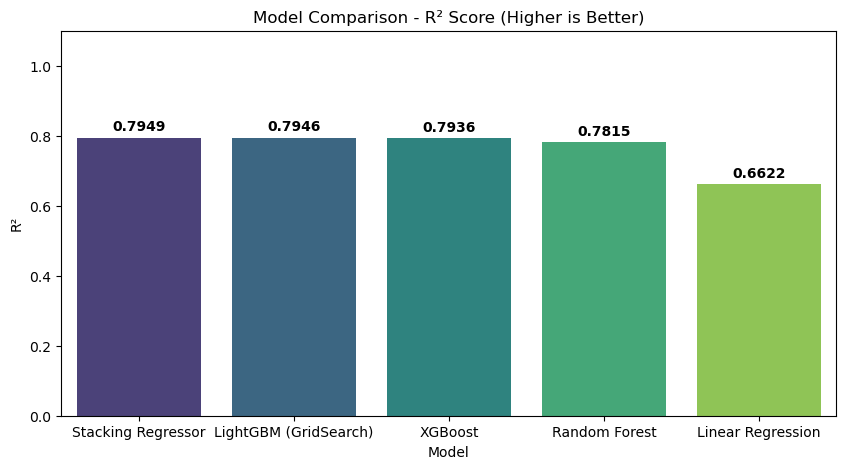

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023915 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3277
[LightGBM] [Info] Number of data points in the train set: 674014, number of used features: 14
[LightGBM] [Info] Start training from score 0.736214


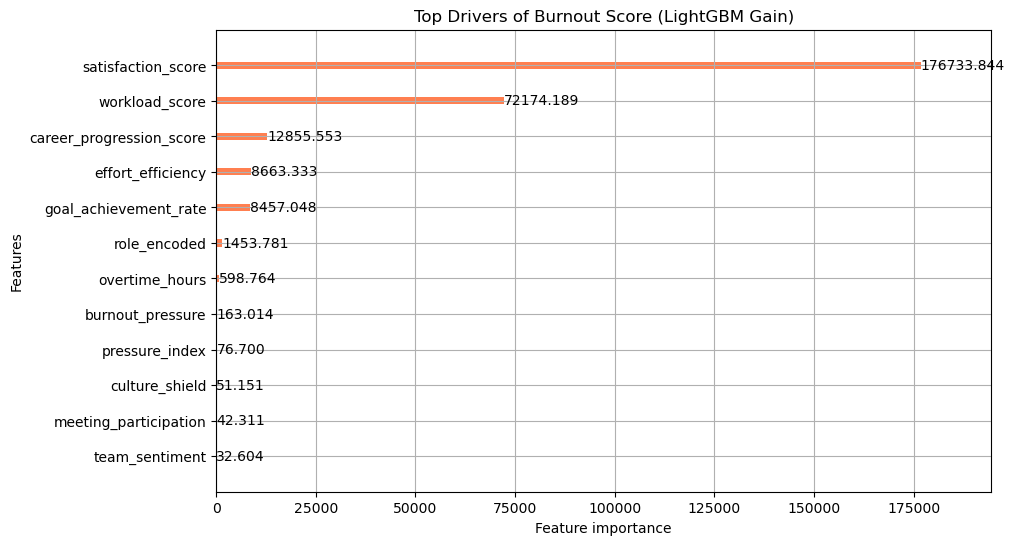

In [17]:
# Convert performance dictionary to DataFrame
results_df = pd.DataFrame(model_performance)

# Sort by R² (Highest is best)
results_df = results_df.sort_values(by='R²', ascending=False).reset_index(drop=True)
display(results_df)

# Plotting the Comparison
plt.figure(figsize=(10, 5))
# sns.barplot(x='Model', y='R²', data=results_df, palette='viridis')
sns.barplot(x='Model', y='R²', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison - R² Score (Higher is Better)')
plt.ylim(0, 1.1)
for i, v in enumerate(results_df['R²']):
    plt.text(i, v + 0.02, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()

# Plotting Feature Importance from LightGBM (Top-performing)
# Note: Re-training LightGBM without scaling for interpretable feature importance
lgb_interpret = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42, n_jobs=-1)
lgb_interpret.fit(X_train, y_train)

lgb.plot_importance(lgb_interpret, max_num_features=12, importance_type='gain',
                    figsize=(10, 6), title='Top Drivers of Burnout Score (LightGBM Gain)',
                    color='coral')
plt.show()